# Planck $Q/U$ Map: Low-pass Filtering and $EE$/$BB$ Power Spectra

**Overview of the pipeline**

We start from a full-sky HEALPix map of the linear polarization Stokes parameters $Q(\hat n)$ and $U(\hat n)$. These are the two components of a spin-2 field on the sphere: under a rotation of the local coordinate axes by an angle $\psi$ at a point $\hat n$,

$$(Q \pm iU)(\hat n) \;\longrightarrow\; e^{\mp 2i\psi}\,(Q \pm iU)(\hat n).$$

Because of this spin-2 character, $Q$ and $U$ cannot be harmonic-transformed independently as if they were ordinary scalar (spin-0) fields — doing so would not correspond to any rotationally well-defined quantity. Instead, the physically meaningful decomposition is into the **$E$-mode** and **$B$-mode** harmonic coefficients $a^E_{lm}$, $a^B_{lm}$, obtained through the spin-weighted spherical harmonics ${}_{\pm2}Y_{lm}$:

$$(Q+iU)(\hat n) = -\sum_{lm}\big(a^E_{lm} + i\,a^B_{lm}\big)\,{}_{-2}Y_{lm}(\hat n), \qquad
(Q-iU)(\hat n) = -\sum_{lm}\big(a^E_{lm} - i\,a^B_{lm}\big)\,{}_{+2}Y_{lm}(\hat n).$$

The notebook below:

1. Loads the recovered full-sky $Q, U$ HEALPix map plus comparison maps.
2. Plots the original $Q, U$ map (Mollweide projection).
3. Applies a smooth (cosine-tapered) low-pass filter in $l$, keeping modes below a chosen effective multipole $l_{\rm eff}$, applied to $a^E_{lm}$ and $a^B_{lm}$ via the spin-2 transform of the $(Q,U)$ pair.
4. Plots the resulting filtered full-sky $Q, U$ map.
5. Computes and plots the $C_l^{EE}$ and $C_l^{BB}$ power spectra: all maps as-is, plus the filtered curve only for the original target map.
6. Repeats the power spectrum estimate restricted to high Galactic latitude ($|b| > 45^\circ$), where the map is not dominated by Galactic-plane foreground residuals, and discusses the mode-coupling this partial-sky cut introduces.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
# Matplotlib math rendering: use built-in MathText, not an external LaTeX installation.
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"
plt.rcParams["mathtext.default"] = "it"



## 1. Load the map

The map is stored as a HEALPix FITS file at some resolution parameter $N_{\rm side}$, which fixes the number of pixels as

$$N_{\rm pix} = 12\,N_{\rm side}^2,$$

each pixel subtending equal solid angle $\Delta\Omega = 4\pi / N_{\rm pix}$. We read fields $1$ and $2$ of the FITS table, corresponding to $Q(\hat n)$ and $U(\hat n)$ (field $0$ is $I$, which we don't use here).

In [2]:
# -------------------------
# Map paths, low-pass parameters, and loading
# -------------------------

VERSION = 4

TARGET_NSIDE = 1024
NSIDE = TARGET_NSIDE

# Low-pass parameters. recovered_f is constructed below using these values.
l_eff = 900          # effective low-pass cutoff multipole
taper_width = 500    # width of the smooth transition band around l_eff

# Franken-map transition: observed at low ell, recovered_f at high ell.
franken_ell = 70
franken_width = 20    # smooth transition from ell=50 to ell=70

map_specs = {
    "recovered": {
        "path": f"/Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/patches2map/fits_files/recovered_v{VERSION}_IQU_nside1024.fits",
        "fields": (1, 2),  # Q, U from I,Q,U
        "label": f"Recovered",
    },
    "MN": {
        "path": "/Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/patches2map/fits_files/MNpatches_v2_QU_nside1024_overlap32px.fits",
        "fields": (1, 2),  # Q, U from I,Q,U; I is zero in this file
        "label": "Moment Network",
    },
    "observed": {
        "path": "/Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/patches2map/fits_files/preprocessed_npipe_iqu_353_wo_CMB_wiener_wo_dip_zodi_MJy_sr_10_arcmin.fits",
        "fields": (1, 2),  # Q, U from I,Q,U
        "label": "Observed",
    },
    "GNILC": {
        "path": "/Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/patches2map/fits_files/gnilc_varres_pr3_MJysr.fits",
        "fields": (1, 2),  # Q, U from I,Q,U
        "label": "GNILC",
    },
    "nuisance": {
        "path": "/Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/patches2map/fits_files/nuisance_Q353_U353_noise_seed_0296_CMB_res_seed_96_v4_10_arcmin_IQU_nside1024_weighted=True.fits",
        "fields": (1, 2),  # Q, U from I,Q,U
        "label": "Nuisance",
    },
}


def make_lowpass_filter(lmax, l_eff, width=100):
    """
    Smooth cosine-tapered low-pass filter in harmonic space.
    """
    ell_local = np.arange(lmax + 1, dtype=float)
    filt = np.ones_like(ell_local)

    l_start = l_eff - width / 2.0
    l_end = l_eff + width / 2.0

    transition = (ell_local >= l_start) & (ell_local <= l_end)
    filt[transition] = 0.5 * (1.0 + np.cos(np.pi * (ell_local[transition] - l_start) / width))
    filt[ell_local > l_end] = 0.0
    filt[ell_local < l_start] = 1.0

    return filt


def downgrade_qu_spin2(Q, U, nside_out, lmax_out=None):
    """
    Harmonic-space resolution change of a polarization map.

    This treats Q/U correctly as a spin-2 field:
        (Q,U) -> (E_lm,B_lm) -> re-synthesized (Q,U).
    """
    nside_in = hp.get_nside(Q)

    if nside_in == nside_out:
        return Q.copy(), U.copy()

    if lmax_out is None:
        lmax_out = 3 * nside_out - 1

    print(f"Changing Q/U resolution from NSIDE={nside_in} to NSIDE={nside_out} with lmax={lmax_out}")

    alm_E, alm_B = hp.map2alm_spin([Q, U], spin=2, lmax=lmax_out)
    Q_out, U_out = hp.alm2map_spin([alm_E, alm_B], nside=nside_out, spin=2, lmax=lmax_out)

    return Q_out, U_out


def load_qu_map(path, fields=(1, 2), nside_out=TARGET_NSIDE):
    """
    Load Q/U from a FITS map and optionally change resolution to nside_out.
    """
    Q, U = hp.read_map(path, field=fields)
    Q = np.asarray(Q)
    U = np.asarray(U)

    nside_in = hp.get_nside(Q)
    if nside_in != nside_out:
        Q, U = downgrade_qu_spin2(Q, U, nside_out=nside_out)

    return Q, U


# Load recovered first.
maps = {}

name = "recovered"
spec = map_specs[name]
print(f"\nLoading {name}: {spec['path']}")
Q_rec, U_rec = load_qu_map(spec["path"], fields=spec["fields"], nside_out=TARGET_NSIDE)

maps[name] = {
    "Q": Q_rec,
    "U": U_rec,
    "label": spec["label"],
    "path": spec["path"],
}

nside = hp.get_nside(Q_rec)
npix = hp.nside2npix(nside)
lmax = 3 * nside - 1

print(f"  NSIDE = {nside}")
print(f"  l_eff = {l_eff}")
print(f"  taper_width = {taper_width}")
print(f"  lmax = {lmax}")

# Construct the filtered recovered map once, then store it as an ordinary map.
filt = make_lowpass_filter(lmax, l_eff, width=taper_width)
alm_E_rec, alm_B_rec = hp.map2alm_spin([Q_rec, U_rec], spin=2, lmax=lmax)
alm_E_rec_f = hp.almxfl(alm_E_rec, filt)
alm_B_rec_f = hp.almxfl(alm_B_rec, filt)
Q_rec_f, U_rec_f = hp.alm2map_spin([alm_E_rec_f, alm_B_rec_f], nside=nside, spin=2, lmax=lmax)

maps["recovered_f"] = {
    "Q": Q_rec_f,
    "U": U_rec_f,
    "label": rf"Recovered",
    "path": spec["path"],
    "filtered_from": "recovered",
    "l_eff": l_eff,
    "taper_width": taper_width,
}

# Load the remaining maps. They are not filtered.
for name in ["MN", "observed", "GNILC", "nuisance"]:
    spec = map_specs[name]
    print(f"\nLoading {name}: {spec['path']}")
    Q, U = load_qu_map(spec["path"], fields=spec["fields"], nside_out=TARGET_NSIDE)

    maps[name] = {
        "Q": Q,
        "U": U,
        "label": spec["label"],
        "path": spec["path"],
    }

    print(f"  Q shape = {Q.shape}")
    print(f"  U shape = {U.shape}")
    print(f"  NSIDE   = {hp.get_nside(Q)}")


# Construct nuisance_f using the same low-pass filter as recovered_f.
Q_nuis = maps["nuisance"]["Q"]
U_nuis = maps["nuisance"]["U"]

alm_E_nuis, alm_B_nuis = hp.map2alm_spin(
    [Q_nuis, U_nuis], spin=2, lmax=lmax
)
alm_E_nuis_f = hp.almxfl(alm_E_nuis, filt)
alm_B_nuis_f = hp.almxfl(alm_B_nuis, filt)

Q_nuis_f, U_nuis_f = hp.alm2map_spin(
    [alm_E_nuis_f, alm_B_nuis_f],
    nside=NSIDE,
    spin=2,
    lmax=lmax,
)

maps["nuisance_f"] = {
    "Q": Q_nuis_f,
    "U": U_nuis_f,
    "label": rf"Nuisance",
    "path": maps["nuisance"]["path"],
    "filtered_from": "nuisance",
    "l_eff": l_eff,
    "taper_width": taper_width,
}


# Construct the Franken map:
#   - observed modes on large angular scales,
#   - recovered_f modes on smaller angular scales,
#   - smooth cosine crossfade around franken_ell.
#
# The two harmonic weights are complementary:
#     w_obs(ell) + w_rec(ell) = 1.
franken_obs_weight = make_lowpass_filter(
    lmax, franken_ell, width=franken_width
)
franken_rec_weight = 1.0 - franken_obs_weight

alm_E_obs, alm_B_obs = hp.map2alm_spin(
    [maps["observed"]["Q"], maps["observed"]["U"]],
    spin=2,
    lmax=lmax,
)
alm_E_rec_f, alm_B_rec_f = hp.map2alm_spin(
    [maps["recovered_f"]["Q"], maps["recovered_f"]["U"]],
    spin=2,
    lmax=lmax,
)

alm_E_franken = (
    hp.almxfl(alm_E_obs, franken_obs_weight)
    + hp.almxfl(alm_E_rec_f, franken_rec_weight)
)
alm_B_franken = (
    hp.almxfl(alm_B_obs, franken_obs_weight)
    + hp.almxfl(alm_B_rec_f, franken_rec_weight)
)

Q_franken, U_franken = hp.alm2map_spin(
    [alm_E_franken, alm_B_franken],
    nside=NSIDE,
    spin=2,
    lmax=lmax,
)

maps["franken"] = {
    "Q": Q_franken,
    "U": U_franken,
    "label": rf"Recovered",
    "low_ell_source": "observed",
    "high_ell_source": "recovered_f",
    "transition_ell": franken_ell,
    "transition_width": franken_width,
}

print(
    f"\nConstructed franken map: observed below ell~{franken_ell}, "
    f"recovered_f above, transition width={franken_width}."
)

# Backwards-compatible variables used by the rest of the notebook.
map_name = "recovered"
selected_map_names = ["recovered", "recovered_f", "franken", "MN", "observed", "GNILC", "nuisance", "nuisance_f"]

Q_map = maps[map_name]["Q"]
U_map = maps[map_name]["U"]

alm_E = alm_E_rec
alm_B = alm_B_rec
Q_filt = maps["recovered_f"]["Q"]
U_filt = maps["recovered_f"]["U"]

print("\nAvailable map keys:")
print(maps.keys())
print(f"nside = {nside}")
print(f"npix  = {npix}")



Loading recovered: /Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/patches2map/fits_files/recovered_v4_IQU_nside1024.fits
  NSIDE = 1024
  l_eff = 900
  taper_width = 500
  lmax = 3071

Loading MN: /Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/patches2map/fits_files/MNpatches_v2_QU_nside1024_overlap32px.fits
  Q shape = (12582912,)
  U shape = (12582912,)
  NSIDE   = 1024

Loading observed: /Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/patches2map/fits_files/preprocessed_npipe_iqu_353_wo_CMB_wiener_wo_dip_zodi_MJy_sr_10_arcmin.fits
  Q shape = (12582912,)
  U shape = (12582912,)
  NSIDE   = 1024

Loading GNILC: /Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/patches2map/fits_files/gnilc_varres_pr3_MJysr.fits
  Q shape = (12582912,)
  U shape = (12582912,)
  NSIDE   = 1024

Loading nuisance: /Users/tsouros/Desktop/Projects/STL-Dev/Planck Project/patches2map/fits_files/nuisance_Q353_U353_noise_seed_0296_CMB_res_seed_96_v4_10_arcmin_IQU_nside1024_weighted=

### Franken map

The `franken` polarization map uses the observed map at low multipoles and the filtered recovered map at higher multipoles. A raised-cosine weight $w_{\rm obs}(\ell)$ is centered at $\ell=60$ with width $20$, and the recovered weight is its complement, $w_{\rm rec}(\ell)=1-w_{\rm obs}(\ell)$. Thus

$$a^{X,\,\mathrm{franken}}_{\ell m}=w_{\rm obs}(\ell)a^{X,\,\mathrm{obs}}_{\ell m}+[1-w_{\rm obs}(\ell)]a^{X,\,\mathrm{rec,f}}_{\ell m},\qquad X\in\{E,B\}.$$

The map is purely observed below $\ell=50$, purely `recovered_f` above $\ell=70$, and smoothly interpolated between them.


In [3]:
# Construct observed_f by applying the same low-pass filter as recovered_f

Q = maps["observed"]["Q"]
U = maps["observed"]["U"]

alm_E, alm_B = hp.map2alm_spin([Q, U], spin=2, lmax=lmax)
alm_E_f = hp.almxfl(alm_E, filt)
alm_B_f = hp.almxfl(alm_B, filt)

Q_f, U_f = hp.alm2map_spin([alm_E_f, alm_B_f], nside=NSIDE, spin=2, lmax=lmax)

maps["observed_f"] = {
    "Q": Q_f,
    "U": U_f,
    "label": rf"Observed"
}


In [4]:
# ------------------------------------------------------------------
# nuisance_franken:
#   low ell  -> zero
#   high ell -> nuisance
# ------------------------------------------------------------------

# Harmonic coefficients of the nuisance map
Q_nuisance = maps["nuisance"]["Q"]
U_nuisance = maps["nuisance"]["U"]

alm_E_nuisance, alm_B_nuisance = hp.map2alm_spin(
    [Q_nuisance, U_nuisance],
    spin=2,
    lmax=lmax,
)

# Same smooth transition as for the Franken map
ell = np.arange(lmax + 1)

l1 = franken_ell - franken_width / 2.0
l2 = franken_ell + franken_width / 2.0

# Low-pass weight: 1 at low ell, 0 at high ell
w_low = np.ones(lmax + 1)
transition = (ell > l1) & (ell < l2)

w_low[ell >= l2] = 0.0
w_low[transition] = 0.5 * (
    1.0
    + np.cos(
        np.pi * (ell[transition] - l1) / (l2 - l1)
    )
)

# Complementary high-pass weight
w_high = 1.0 - w_low

# Low-ell contribution is exactly zero, so only the
# high-pass-filtered nuisance harmonics remain
alm_E_nuisance_franken = hp.almxfl(
    alm_E_nuisance,
    w_high,
)

alm_B_nuisance_franken = hp.almxfl(
    alm_B_nuisance,
    w_high,
)

Q_nuisance_franken, U_nuisance_franken = hp.alm2map_spin(
    [alm_E_nuisance_franken, alm_B_nuisance_franken],
    nside=TARGET_NSIDE,
    spin=2,
    lmax=lmax,
)

maps["nuisance_franken"] = {
    "Q": Q_nuisance_franken,
    "U": U_nuisance_franken,
    "label": "Nuisance",
}

## 2. Plot full sky maps

Simple Mollweide (equal-area, whole-sky) projections of $Q(\hat n)$ and $U(\hat n)$, with no processing applied yet.

In [5]:
print(maps.keys())

dict_keys(['recovered', 'recovered_f', 'MN', 'observed', 'GNILC', 'nuisance', 'nuisance_f', 'franken', 'observed_f', 'nuisance_franken'])


In [6]:
def math_label(text):
    """
    Return a Matplotlib-safe title/legend string.

    Pass LaTeX only inside balanced dollar signs, for example:
        math_label(r"Recovered filtered ($\ell_{\mathrm{eff}}=900$)")
    """
    if not isinstance(text, str):
        text = str(text)

    if text.count("$") % 2 != 0:
        raise ValueError(f"Unbalanced '$' delimiters in label: {text!r}")

    return text

def _plot_qu_arrays(
    Q,
    U,
    q_title="Q",
    u_title="U",
    figure_title=None,
    vlim=0.1,
    cmap="RdBu_r",
    dpi=180,
    save=None,
    figsize=(12, 12),
    xsize=1600,
):
    """
    Shared renderer for all full-sky Q/U figures.

    All maps use identical:
      - canvas dimensions
      - Mollweide dimensions
      - subplot spacing
      - colour-bar geometry
      - save settings
    """

    fig = plt.figure(figsize=figsize, dpi=dpi)

    hp.mollview(
        Q,
        sub=(2, 1, 1),
        fig=fig.number,
        title=math_label(q_title),
        unit="MJy/sr",
        cmap=cmap,
        min=-vlim,
        max=+vlim,
        xsize=xsize,
        margins=(0.02, 0.02, 0.02, 0.02),
    )

    hp.mollview(
        U,
        sub=(2, 1, 2),
        fig=fig.number,
        title=math_label(u_title),
        unit="MJy/sr",
        cmap=cmap,
        min=-vlim,
        max=+vlim,
        xsize=xsize,
        margins=(0.02, 0.02, 0.02, 0.02),
    )

    if figure_title is not None:
        fig.suptitle(math_label(figure_title), fontsize=18, y=0.995)

    fig.subplots_adjust(
        left=0.015,
        right=0.985,
        bottom=0.015,
        top=0.96 if figure_title is not None else 0.985,
        hspace=0.08,
    )

    if save is not None:
        fig.savefig(
            save,
            dpi=dpi,
            bbox_inches="tight",
            pad_inches=0,
        )

    plt.show()


def plot_qu_fullsky(
    name,
    vlim=0.1,
    cmap="RdBu_r",
    dpi=180,
    save=None,
    title=None,
):
    """
    Plot Q/U for a map in the maps dictionary.
    """
    if name not in maps:
        raise KeyError(
            f"Unknown map {name!r}. Available keys: {list(maps.keys())}"
        )

    label = maps[name].get("label", name)

    _plot_qu_arrays(
        maps[name]["Q"],
        maps[name]["U"],
        q_title=f"{label} Q",
        u_title=f"{label} U",
        figure_title=title,
        vlim=vlim,
        cmap=cmap,
        dpi=dpi,
        save=save,
    )


def plot_qu_difference(
    map1,
    map2,
    vlim=0.05,
    cmap="RdBu_r",
    dpi=180,
    save=None,
    title=None
):
    """
    Plot the full-sky residual map map1 - map2.
    """
    if map1 not in maps or map2 not in maps:
        raise KeyError(
            f"Available keys: {list(maps.keys())}"
        )

    label1 = maps[map1].get("label", map1)
    label2 = maps[map2].get("label", map2)

    Q_res = maps[map1]["Q"] - maps[map2]["Q"]
    U_res = maps[map1]["U"] - maps[map2]["U"]

    _plot_qu_arrays(
        Q_res,
        U_res,
        q_title=f"Q residual: {label1} − {label2}",
        u_title=f"U residual: {label1} − {label2}",
        figure_title=title,
        vlim=vlim,
        cmap=cmap,
        dpi=dpi,
        save=save,
    )

In [7]:
# Full-sky plotting helpers are defined in the preceding cell.


In [8]:
print(maps.keys())

dict_keys(['recovered', 'recovered_f', 'MN', 'observed', 'GNILC', 'nuisance', 'nuisance_f', 'franken', 'observed_f', 'nuisance_franken'])


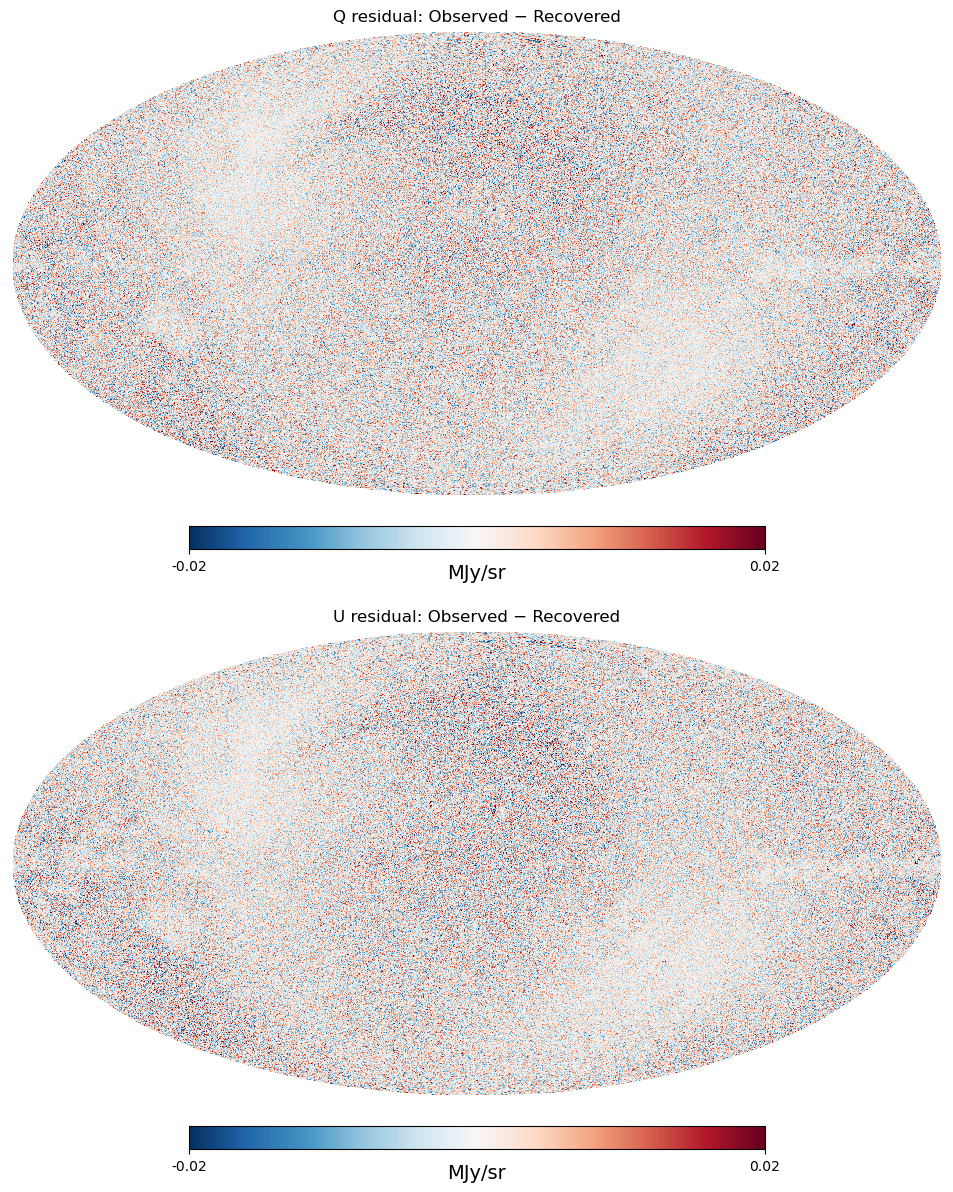

In [9]:
plot_qu_difference("observed_f", "franken", vlim=0.02, save = f'res_v{VERSION}.png', dpi = 100)

## Low-$\ell$ filtering of the residual map

Let the residual polarization map be

$$
R(\hat{\mathbf n}) =
\begin{pmatrix}
Q(\hat{\mathbf n})\\
U(\hat{\mathbf n})
\end{pmatrix}.
$$

The map is first transformed into spherical harmonic space,

$$
(Q,U)
\;\longrightarrow\;
(a_{\ell m}^{E},\,a_{\ell m}^{B}),
$$

where $a_{\ell m}^{E}$ and $a_{\ell m}^{B}$ are the $E$- and $B$-mode harmonic coefficients.

To isolate only the large angular scales, we choose a multipole cutoff
$\ell_{\rm max}^{\rm low}$ and apply the filter

$$
a_{\ell m}^{E,\mathrm{low}} =
\begin{cases}
a_{\ell m}^{E}, & \ell \le \ell_{\rm max}^{\rm low},\\
0, & \ell > \ell_{\rm max}^{\rm low},
\end{cases}
$$

and similarly,

$$
a_{\ell m}^{B,\mathrm{low}} =
\begin{cases}
a_{\ell m}^{B}, & \ell \le \ell_{\rm max}^{\rm low},\\
0, & \ell > \ell_{\rm max}^{\rm low}.
\end{cases}
$$

Finally, an inverse spherical harmonic transform is performed,

$$
(a_{\ell m}^{E,\mathrm{low}},a_{\ell m}^{B,\mathrm{low}})
\;\longrightarrow\;
(Q_{\rm low},U_{\rm low}),
$$

yielding a map that contains only spherical harmonic modes with

$$
\ell \le \ell_{\rm max}^{\rm low}.
$$

Since angular scale is approximately related to multipole by

$$
\theta \simeq \frac{180^\circ}{\ell},
$$

this operation removes small-scale structure while preserving only the large-scale residuals. It is therefore a sharp low-pass filter in spherical harmonic space.

/var/folders/7v/7hfv67116xdb9qv3t1yztbsh0000gp/T/ipykernel_43590/3292007089.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


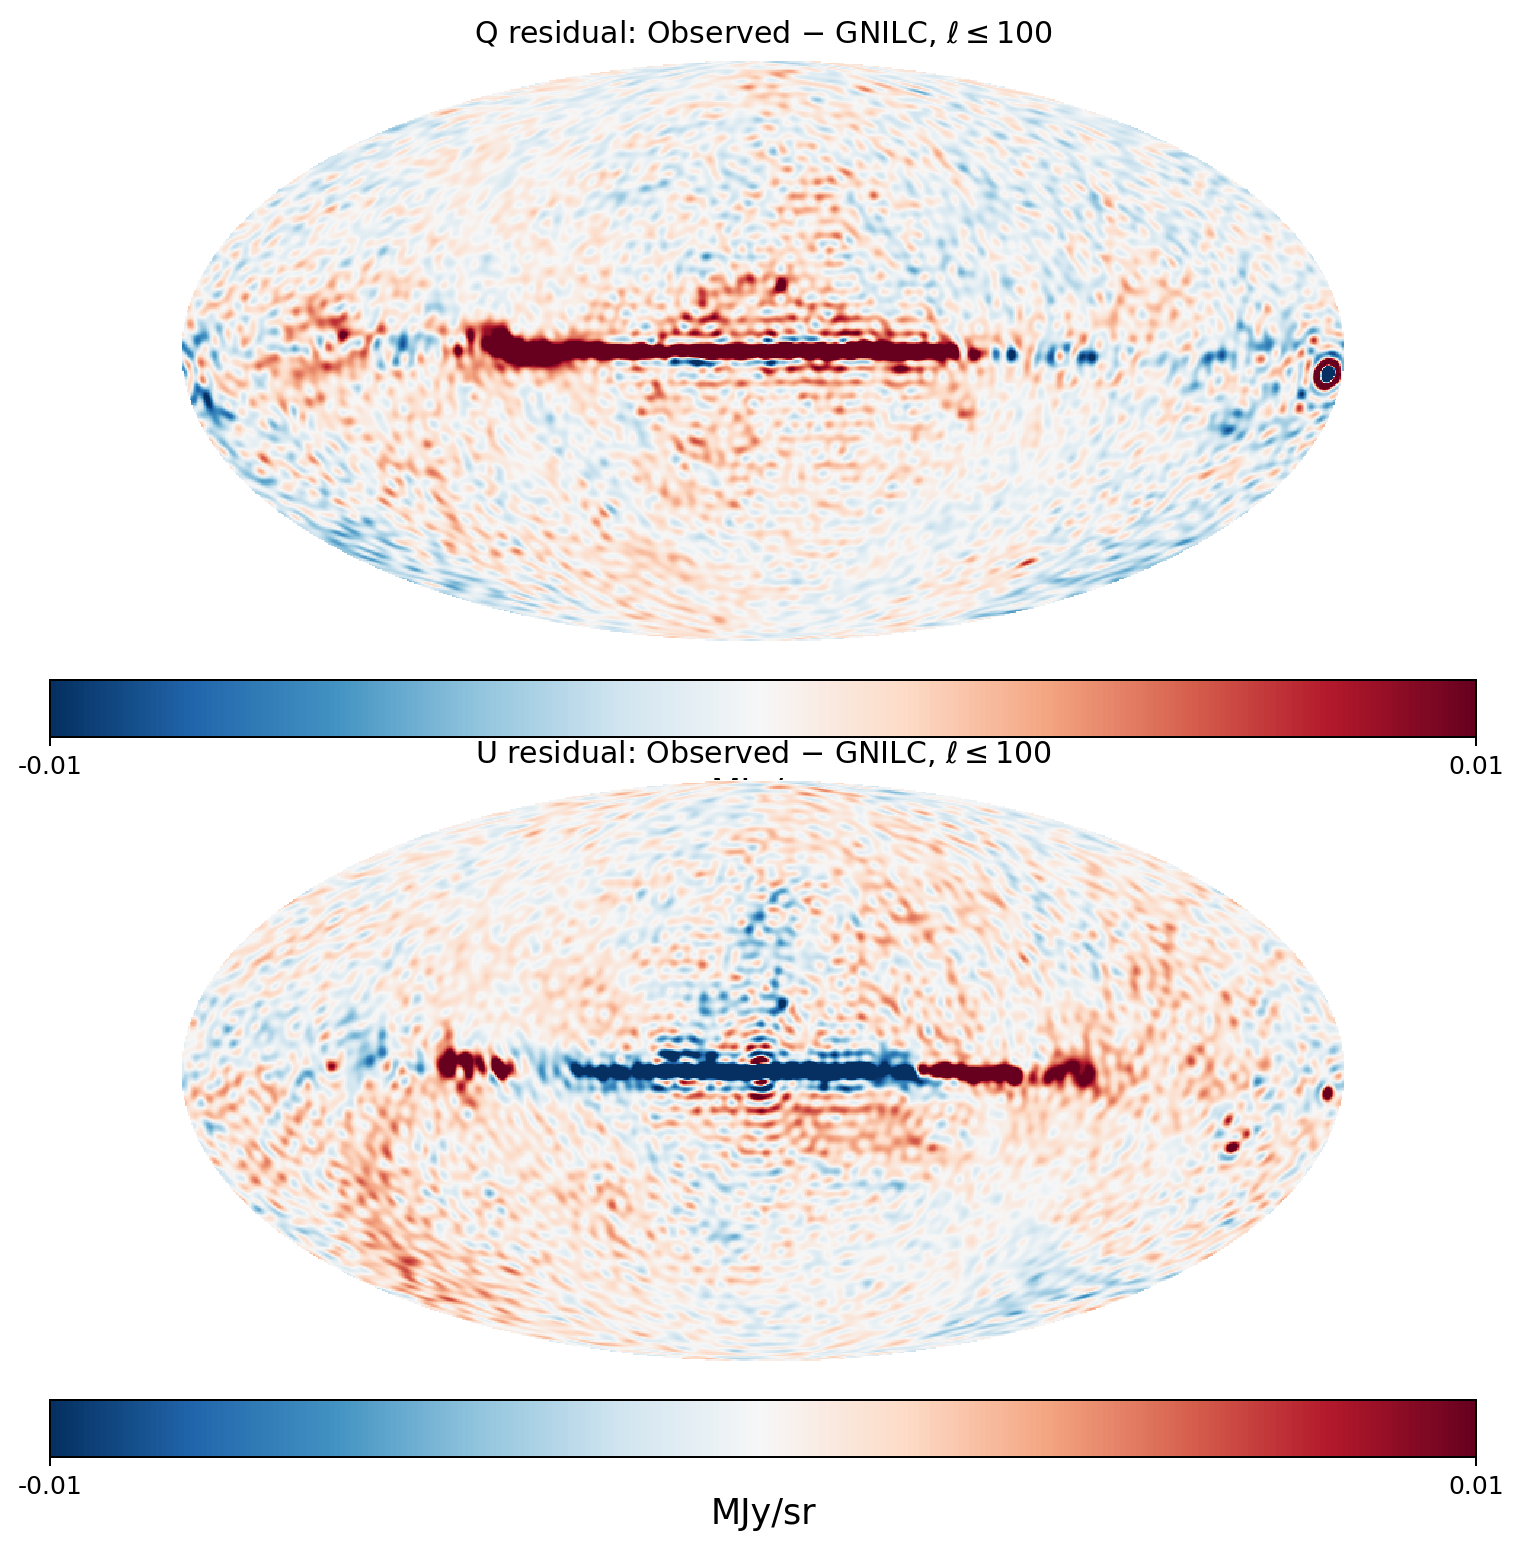

In [10]:
# Low-ell residual map: keep only modes below a chosen multipole

residual_map1 = "observed_f"
residual_map2 = "GNILC"
residual_lmax_keep = 100   # change this to choose the largest ell kept
residual_vlim = 0.01
residual_cmap = "RdBu_r"
residual_filename = f"residual_lowell_{residual_map2}.png"

label1 = maps[residual_map1]["label"]
label2 = maps[residual_map2]["label"]

# Residual Q/U map.
Q_res = maps[residual_map1]["Q"] - maps[residual_map2]["Q"]
U_res = maps[residual_map1]["U"] - maps[residual_map2]["U"]

# Spin-2 harmonic transform of the residual.
alm_E_res, alm_B_res = hp.map2alm_spin([Q_res, U_res], spin=2, lmax=lmax)

# Sharp low-pass: keep ell <= residual_lmax_keep, remove ell > residual_lmax_keep.
ell_filter = np.arange(lmax + 1)
lowell_filter = (ell_filter <= residual_lmax_keep).astype(float)

alm_E_res_low = hp.almxfl(alm_E_res, lowell_filter)
alm_B_res_low = hp.almxfl(alm_B_res, lowell_filter)

Q_res_low, U_res_low = hp.alm2map_spin(
    [alm_E_res_low, alm_B_res_low],
    nside=NSIDE,
    spin=2,
    lmax=lmax,
)

fig = plt.figure(figsize=(16, 8), dpi = 180)

hp.mollview(
    Q_res_low,
    sub=(2, 1, 1),
    fig=fig.number,
    title=rf"Q residual: {label1} − {label2}, $\ell \leq {residual_lmax_keep}$",
    # title=rf"Q nuisance",
    cmap=residual_cmap,
    min=-residual_vlim,
    max=residual_vlim,
    unit="MJy/sr",
)

hp.mollview(
    U_res_low,
    sub=(2, 1, 2),
    fig=fig.number,
    title=rf"U residual: {label1} − {label2}, $\ell \leq {residual_lmax_keep}$",   
    # title=rf"U nuisance",   
    cmap=residual_cmap,
    min=-residual_vlim,
    max=residual_vlim,
    unit="MJy/sr",
)

plt.tight_layout()
plt.savefig(residual_filename, dpi = 100)
plt.show()



## 3. The forward and inverse spin-2 transform

Inverting the spin-2 expansion above gives the analysis equations (Zaldarriaga & Seljak 1997):

$$a^E_{lm} = -\frac{1}{2}\int d\Omega\;\Big[(Q+iU)(\hat n)\,{}_{-2}Y^{*}_{lm}(\hat n) + (Q-iU)(\hat n)\,{}_{+2}Y^{*}_{lm}(\hat n)\Big],$$

$$a^B_{lm} = \phantom{-}\frac{i}{2}\int d\Omega\;\Big[(Q+iU)(\hat n)\,{}_{-2}Y^{*}_{lm}(\hat n) - (Q-iU)(\hat n)\,{}_{+2}Y^{*}_{lm}(\hat n)\Big].$$

Notice that **both** $a^E_{lm}$ and $a^B_{lm}$ are built from an integral over the sky that involves $Q(\hat n)$ *and* $U(\hat n)$ jointly, weighted by complex spin-weighted harmonics at every point. There is no way to split this into "a transform of $Q$" plus "a transform of $U$" performed independently — this is why the transform below is called on the pair `[Q_map, U_map]` in a single function call (`healpy.map2alm_spin`, with `spin=2`), rather than being run once per map.

The inverse relation reconstructs $Q, U$ from $a^E_{lm}, a^B_{lm}$:

$$Q(\hat n) \pm iU(\hat n) = -\sum_{lm}\big(a^E_{lm} \pm i\,a^B_{lm}\big)\,{}_{\mp2}Y_{lm}(\hat n),$$

implemented by `healpy.alm2map_spin`.

## 4. The low-pass filter

We want to suppress harmonic modes above some effective multipole $l_{\rm eff}$, smoothly rather than with a hard cut (a hard top-hat cutoff in $l$ is equivalent to convolving the map with a sinc-like function in real space, which produces ringing / Gibbs oscillations around sharp features). Instead we use a **raised-cosine (Hann) taper**, applied as a diagonal weight in $l$ — the same weight for every $m$, and applied identically to $a^E_{lm}$ and $a^B_{lm}$:

$$\tilde a^X_{lm} = f(l)\,a^X_{lm}, \qquad X \in \{E, B\},$$

with, for cutoff $l_{\rm eff}$ and transition width $\Delta$:

$$
f(l) =
\begin{cases}
1, & l \le l_{\rm eff} - \Delta/2 \\[4pt]
\dfrac{1}{2}\Big[1 + \cos\!\Big(\pi\,\dfrac{l - (l_{\rm eff}-\Delta/2)}{\Delta}\Big)\Big], & l_{\rm eff}-\Delta/2 < l < l_{\rm eff}+\Delta/2 \\[8pt]
0, & l \ge l_{\rm eff} + \Delta/2.
\end{cases}
$$

This function is continuous with zero derivative at both ends of the transition band (i.e. $C^1$-smooth everywhere), which is what suppresses ringing relative to a hard cutoff. $f(l_{\rm eff}) = 1/2$ exactly at the nominal cutoff.

In [11]:
def make_lowpass_filter(lmax, l_eff, width=100):
    """
    Smooth (cosine-tapered) low-pass filter in harmonic space.

    Parameters
    ----------
    lmax : int
        Maximum multipole of the alm expansion.
    l_eff : float
        Effective cutoff multipole (center of the transition band).
    width : float
        Width of the cosine transition band, centered on l_eff.
        The filter is 1 below (l_eff - width/2) and 0 above (l_eff + width/2).

    Returns
    -------
    filt : ndarray, shape (lmax + 1,)
        Filter values f(l) as a function of l = 0 ... lmax.
    """
    l = np.arange(lmax + 1, dtype=float)
    filt = np.ones_like(l)

    l_start = l_eff - width / 2.0
    l_end = l_eff + width / 2.0

    transition = (l >= l_start) & (l <= l_end)
    filt[transition] = 0.5 * (1.0 + np.cos(np.pi * (l[transition] - l_start) / width))
    filt[l > l_end] = 0.0
    filt[l < l_start] = 1.0

    return filt

## 5. Set parameters and apply the filter

$l_{\rm eff}$ and the taper width $\Delta$ are set here. The maximum representable multipole for a given $N_{\rm side}$ is $l_{\rm max} = 3N_{\rm side}-1$ (the HEALPix band-limit); we use that as the default working $l_{\rm max}$.

The filtering operation is:

1. Forward transform: $(Q,U) \xrightarrow{\text{spin-2}} (a^E_{lm}, a^B_{lm})$.
2. Multiply: $\tilde a^E_{lm} = f(l)\,a^E_{lm}$, $\tilde a^B_{lm} = f(l)\,a^B_{lm}$.
3. Inverse transform: $(\tilde a^E_{lm}, \tilde a^B_{lm}) \xrightarrow{\text{spin-2}} (\tilde Q, \tilde U)$.

In [12]:

# Parameters were defined near the top, before recovered_f was constructed.
# To change the filtering, edit l_eff / taper_width in the first loading cell and rerun from there.

print(f"l_eff       = {l_eff}")
print(f"taper_width = {taper_width}")
print(f"lmax        = {lmax}")
print("Available map keys:", list(maps.keys()))


l_eff       = 900
taper_width = 500
lmax        = 3071
Available map keys: ['recovered', 'recovered_f', 'MN', 'observed', 'GNILC', 'nuisance', 'nuisance_f', 'franken', 'observed_f', 'nuisance_franken']


In [13]:

# Compute harmonic coefficients for every map in the maps dictionary.
# recovered_f is already filtered and is treated exactly like the other maps here.

for name in maps:
    Q = maps[name]["Q"]
    U = maps[name]["U"]

    alm_E, alm_B = hp.map2alm_spin([Q, U], spin=2, lmax=lmax)

    maps[name]["alm_E"] = alm_E
    maps[name]["alm_B"] = alm_B

# Backwards-compatible variables for the original and filtered recovered maps.
alm_E = maps["recovered"]["alm_E"]
alm_B = maps["recovered"]["alm_B"]
Q_map = maps["recovered"]["Q"]
U_map = maps["recovered"]["U"]
Q_filt = maps["recovered_f"]["Q"]
U_filt = maps["recovered_f"]["U"]


## 6. Plot the filtered map

The same Mollweide projections as in Section 2, now for $\tilde Q(\hat n)$ and $\tilde U(\hat n)$ — the modes above $l_{\rm eff}$ have been smoothly removed, so this map should look visibly smoother (less small-scale structure) than the original.

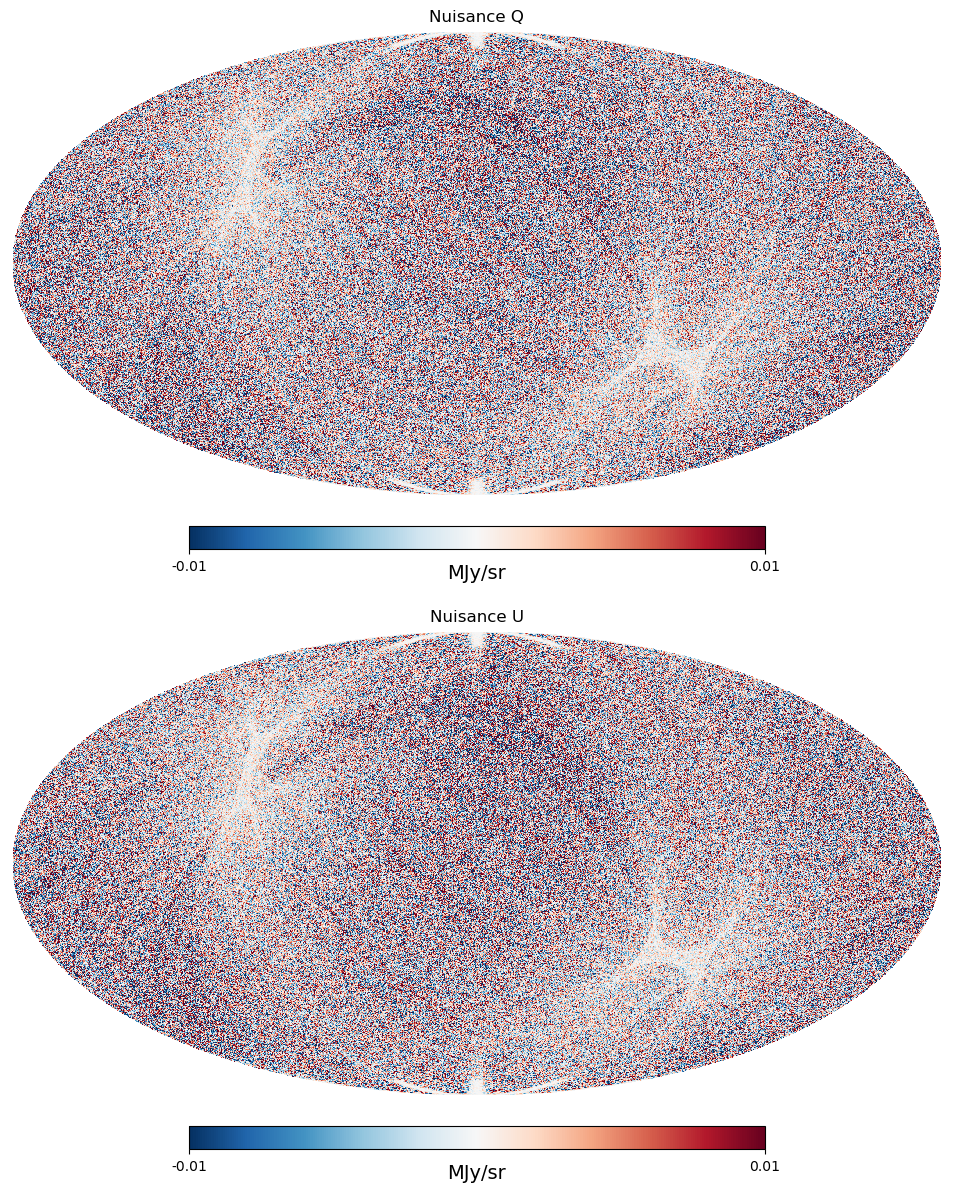

In [14]:

# Plot the filtered recovered map using the same full-sky plotting function.
plot_qu_fullsky("nuisance_f", vlim=0.01, save = 'nuisance.png', dpi = 100)


## 7. $EE$ and $BB$ power spectra: original vs. filtered

For a statistically isotropic field on the full sky, the angular power spectrum is defined as

$$C_l^{XX} = \frac{1}{2l+1}\sum_{m=-l}^{l} \big\langle |a^X_{lm}|^2\big\rangle, \qquad X \in \{E,B\},$$

where the average is over realizations (in practice, for a single sky, we use the $m$-sum itself as the estimator — this is exactly what `healpy.alm2cl` computes from a set of $a_{lm}$'s).

Since the filter multiplies every $a^X_{lm}$ by $f(l)$, the filtered spectrum is related to the original one by

$$\tilde C_l^{XX} = f(l)^2\, C_l^{XX},$$

i.e. the filter's effect on the power spectrum is just multiplication by $f(l)^2$ — exactly what the comparison plot below should show.

In [15]:

for name in maps:
    maps[name]["cl_EE"] = hp.alm2cl(maps[name]["alm_E"], lmax=lmax)
    maps[name]["cl_BB"] = hp.alm2cl(maps[name]["alm_B"], lmax=lmax)

# Backwards-compatible variables.
cl_EE_orig = maps["recovered"]["cl_EE"]
cl_BB_orig = maps["recovered"]["cl_BB"]
cl_EE_filt = maps["recovered_f"]["cl_EE"]
cl_BB_filt = maps["recovered_f"]["cl_BB"]

ell = np.arange(lmax + 1)
dl_factor = ell * (ell + 1) / (2 * np.pi)

# ----- Binning helper for smoother spectra -----
def bin_spectrum(ell, Dl, bin_width=50, ell_min=2, ell_max=None, return_std=False):
    """
    Bin D_ell in linear ell bins.

    If return_std=True, also returns the 1-sigma scatter of the D_ell values
    inside each bin. This is a descriptive within-bin scatter, not a full
    covariance estimate.
    """
    if ell_max is None:
        ell_max = int(np.nanmax(ell))

    ell = np.asarray(ell)
    Dl = np.asarray(Dl)

    edges = np.arange(ell_min, ell_max + bin_width, bin_width)
    ell_binned = []
    Dl_binned = []
    Dl_std_binned = []

    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = (ell >= lo) & (ell < hi) & np.isfinite(Dl) & (Dl > 0)
        if np.any(in_bin):
            vals = Dl[in_bin]
            ell_binned.append(np.mean(ell[in_bin]))
            Dl_binned.append(np.mean(vals))
            Dl_std_binned.append(np.std(vals, ddof=1) if vals.size > 1 else 0.0)

    ell_binned = np.asarray(ell_binned)
    Dl_binned = np.asarray(Dl_binned)
    Dl_std_binned = np.asarray(Dl_std_binned)

    if return_std:
        return ell_binned, Dl_binned, Dl_std_binned
    return ell_binned, Dl_binned

# Change this number to control how smooth/noisy the spectra look.
# Larger bin_width => smoother curves, less ell-resolution.
bin_width = 50


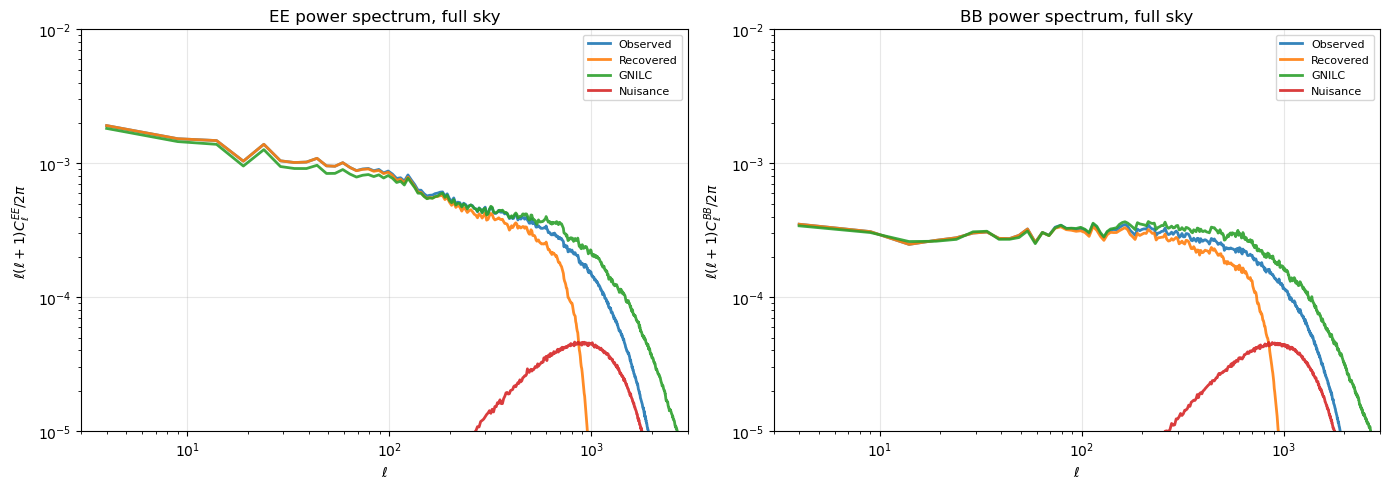

In [16]:
# ----- Which maps/curves to show -----
# Choose any subset of:
# ['recovered', 'recovered_f', 'franken', 'MN', 'observed', 'observed_f', 'GNILC', 'nuisance', 'nuisance_f']
selected_map_names = ["observed", "franken", 'GNILC', 'nuisance']

# ----- Plot limits (set to None for automatic) -----
xlim = (3, 3000)
ylim_EE = (1e-5, 1e-2)
ylim_BB = (1e-5, 1e-2)

# ----- Binning -----
bin_width = 5   # try 25, 50, 100 depending on how smooth you want it

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in selected_map_names:
    label = maps[name]["label"]

    Dl_EE = dl_factor * maps[name]["cl_EE"]
    Dl_BB = dl_factor * maps[name]["cl_BB"]

    ell_EE_b, Dl_EE_b = bin_spectrum(
        ell, Dl_EE, bin_width=bin_width, ell_min=2
    )
    ell_BB_b, Dl_BB_b = bin_spectrum(
        ell, Dl_BB, bin_width=bin_width, ell_min=2
    )

    axes[0].plot(
        ell_EE_b,
        Dl_EE_b,
        label=label,
        lw=2.0,
        alpha=0.9,
    )

    axes[1].plot(
        ell_BB_b,
        Dl_BB_b,
        label=label,
        lw=2.0,
        alpha=0.9,
    )

axes[0].set_xlabel(r"$\ell$")
axes[0].set_ylabel(r"$\ell(\ell+1)C_\ell^{EE}/2\pi$")
axes[0].set_title("EE power spectrum, full sky")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
if xlim is not None:
    axes[0].set_xlim(*xlim)
if ylim_EE is not None:
    axes[0].set_ylim(*ylim_EE)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel(r"$\ell$")
axes[1].set_ylabel(r"$\ell(\ell+1)C_\ell^{BB}/2\pi$")
axes[1].set_title("BB power spectrum, full sky")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
if xlim is not None:
    axes[1].set_xlim(*xlim)
if ylim_BB is not None:
    axes[1].set_ylim(*ylim_BB)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"PS_full_v{VERSION}.png", dpi = 100)
plt.show()

## 8. High Galactic latitude cut ($|b| > 45^\circ$)

The full-sky spectrum above is dominated at low $l$ by Galactic synchrotron and dust polarization, concentrated near the Galactic plane ($b \approx 0^\circ$). To look at a region less contaminated by these foregrounds, we restrict the map to Galactic latitudes $|b| > b_{\rm cut}$, with $b_{\rm cut} = 45^\circ$ chosen here (adjustable below).

**Constructing the cut.** For each pixel $p$, HEALPix gives the colatitude $\theta_p \in [0,\pi]$ and longitude $\phi_p$ of the pixel center. Assuming the map is stored in Galactic coordinates (standard for Planck products), the Galactic latitude is

$$b_p = 90^\circ - \theta_p^{\deg}.$$

The binary mask is then

$$
M(\hat n_p) =
\begin{cases}
1, & |b_p| > b_{\rm cut} \\
0, & |b_p| \le b_{\rm cut}.
\end{cases}
$$

**Effect on the power spectrum estimate.** Multiplying the map by a mask before taking the harmonic transform is equivalent to convolving the true, full-sky harmonic coefficients with the harmonic transform of the mask itself. This means the masked-sky ("pseudo-$C_l$") estimate $\tilde C_l$ is related to the true full-sky spectrum $C_l$ by a **mode-coupling** relation (Hivon et al. 2002, the MASTER formalism),

$$\big\langle \tilde C_l \big\rangle = \sum_{l'} M_{ll'}\, C_{l'},$$

where the coupling matrix $M_{ll'}$ is itself determined by the power spectrum of the mask, $W_l = \frac{1}{2l+1}\sum_m |w_{lm}|^2$ (with $w_{lm}$ the harmonic coefficients of $M(\hat n)$). In particular, a **sharp** mask edge (as used here, with no apodization) has a $W_l$ with substantial power extending to high $l$, so $\tilde C_l$ at a given multipole mixes in true power from a broad range of neighboring multipoles $l'$ — this is the same leakage mechanism that couples $E$ and $B$ under an arbitrary sky cut.

A common **first-order** approximate correction is the mean-power-loss ("naive $f_{\rm sky}$") correction,

$$\hat C_l \approx \frac{\tilde C_l}{f_{\rm sky}}, \qquad f_{\rm sky} = \frac{1}{N_{\rm pix}}\sum_p M(\hat n_p),$$

which corrects the overall normalization but **not** the $l$-$l'$ mode-coupling or $E$/$B$ leakage. We apply this simple rescaling below and plot the result, but a rigorous unbiased estimate would require the full MASTER deconvolution (and, ideally, an apodized rather than a sharp mask) — flagged here rather than implemented, since the goal of this section is just to look at the high-latitude spectrum shape.

In [17]:
b_cut_deg = 35.0  # Galactic latitude cut in degrees; |b| > b_cut_deg is kept

theta, phi = hp.pix2ang(nside, np.arange(npix))
galactic_lat_deg = 90.0 - np.degrees(theta)

mask = np.abs(galactic_lat_deg) > b_cut_deg
f_sky = mask.sum() / npix

print(f"b_cut     = {b_cut_deg} deg")
print(f"f_sky     = {f_sky:.4f}  ({mask.sum()} of {npix} pixels kept)")

b_cut     = 35.0 deg
f_sky     = 0.4261  (5361664 of 12582912 pixels kept)


In [18]:
# fig = plt.figure(figsize=(16, 4))
# hp.mollview(mask.astype(float), title=f"High Galactic latitude mask (|b| > {b_cut_deg:.0f} deg)",
#             cmap="Greys", cbar=False, fig=fig.number)
# plt.tight_layout()
# plt.show()

Apply the mask to both the original and the filtered $Q,U$ maps (masked-out pixels set to zero), then repeat the spin-2 transform and power spectrum estimate as in Sections 3 and 7, this time on the cut sky.

In [19]:

for name in maps:
    Q_masked = np.where(mask, maps[name]["Q"], 0.0)
    U_masked = np.where(mask, maps[name]["U"], 0.0)

    alm_E_cut, alm_B_cut = hp.map2alm_spin([Q_masked, U_masked], spin=2, lmax=lmax)

    maps[name]["cl_EE_cut"] = hp.alm2cl(alm_E_cut, lmax=lmax) / f_sky
    maps[name]["cl_BB_cut"] = hp.alm2cl(alm_B_cut, lmax=lmax) / f_sky

# Backwards-compatible variables.
cl_EE_cut = maps["recovered"]["cl_EE_cut"]
cl_BB_cut = maps["recovered"]["cl_BB_cut"]
cl_EE_cut_filt = maps["recovered_f"]["cl_EE_cut"]
cl_BB_cut_filt = maps["recovered_f"]["cl_BB_cut"]


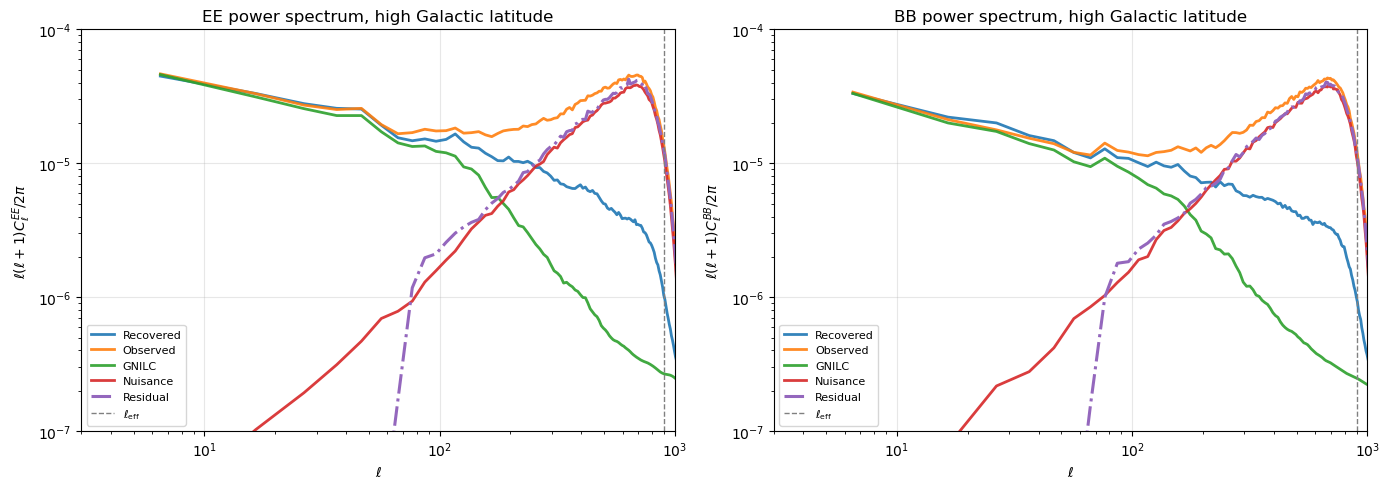

In [20]:

# ----- User-facing labels -----
# Change the display names here.
plot_labels = {
    "recovered": "Recovered_ST",
    "recovered_f": "Recovered",
    "franken": "Recovered",
    "MN": "Moment Network",
    "observed": "Observed",
    "observed_f": "Observed",
    "GNILC": "GNILC",
    "nuisance": "Nuisance",
    "nuisance_f": "Nuisance",
}

# ----- Which auto-spectra to show -----
selected_map_names = ["recovered_f", "observed_f", "GNILC", "nuisance_f"]

# ----- Which cross-spectra to show -----
# Each item is:
#     (map_1, map_2, explicit_label)
# Set to [] if you do not want cross-spectra.
selected_cross_pairs = [
    # ("recovered_f", "observed_f", "Recovered filtered × Observed filtered"),
]

# ----- Which difference-map spectra to show -----
# Each item is:
#     (map_1, map_2, explicit_label)
# This computes the power spectrum of map_1 - map_2.
selected_difference_pairs = [
    ("observed_f", "franken", "Residual"),
]

# ----- Plot limits (set to None for automatic) -----
xlim = (3, 1000)
ylim_EE = (1e-7, 1e-4)
ylim_BB = (1e-7, 1e-4)

# ----- Binning -----
bin_width = 10
sigma_map_name = f"recovered_v{VERSION}_f"
sigma_floor = 1e-30


def get_highlat_cross_spectra(name1, name2, lmax=lmax):
    """
    Compute pseudo-cross-spectra between two maps on the high-latitude mask.
    """
    q1 = maps[name1]["Q"].copy()
    u1 = maps[name1]["U"].copy()
    q2 = maps[name2]["Q"].copy()
    u2 = maps[name2]["U"].copy()

    q1[~mask_high_lat] = 0.0
    u1[~mask_high_lat] = 0.0
    q2[~mask_high_lat] = 0.0
    u2[~mask_high_lat] = 0.0

    t0 = np.zeros_like(q1)

    cl_cross = hp.anafast(
        [t0, q1, u1],
        [t0, q2, u2],
        lmax=lmax,
        pol=True,
    )

    return (
        cl_cross[1] / sky_frac_high_lat,
        cl_cross[2] / sky_frac_high_lat,
    )


def get_highlat_difference_spectra(name1, name2, b_cut_deg=45.0, lmax=lmax):
    """
    Compute the pseudo-auto-spectrum of the difference map

        map_1 - map_2

    restricted to |b| > b_cut_deg.
    """

    nside = hp.get_nside(maps[name1]["Q"])
    npix = hp.nside2npix(nside)

    pix = np.arange(npix)
    _, b = hp.pix2ang(nside, pix, lonlat=True)

    mask = np.abs(b) > b_cut_deg
    fsky = mask.mean()

    q = maps[name1]["Q"] - maps[name2]["Q"]
    u = maps[name1]["U"] - maps[name2]["U"]

    q = q.copy()
    u = u.copy()

    q[~mask] = 0.0
    u[~mask] = 0.0

    cl = hp.anafast(
        [np.zeros_like(q), q, u],
        lmax=lmax,
        pol=True,
    )

    cl_EE = cl[1] / fsky
    cl_BB = cl[2] / fsky

    return cl_EE, cl_BB


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============================================================
# Auto-spectra
# ============================================================
for name in selected_map_names:
    label = plot_labels.get(name, maps[name].get("label", name))

    Dl_EE_cut = dl_factor * maps[name]["cl_EE_cut"]
    Dl_BB_cut = dl_factor * maps[name]["cl_BB_cut"]

    if name == sigma_map_name:
        ell_EE_b, Dl_EE_b, sig_EE_b = bin_spectrum(
            ell, Dl_EE_cut, bin_width=bin_width, ell_min=2, return_std=True
        )
        ell_BB_b, Dl_BB_b, sig_BB_b = bin_spectrum(
            ell, Dl_BB_cut, bin_width=bin_width, ell_min=2, return_std=True
        )
    else:
        ell_EE_b, Dl_EE_b = bin_spectrum(
            ell, Dl_EE_cut, bin_width=bin_width, ell_min=2
        )
        ell_BB_b, Dl_BB_b = bin_spectrum(
            ell, Dl_BB_cut, bin_width=bin_width, ell_min=2
        )

    line_EE, = axes[0].plot(
        ell_EE_b,
        Dl_EE_b,
        label=label,
        lw=2.0,
        alpha=0.9,
    )
    line_BB, = axes[1].plot(
        ell_BB_b,
        Dl_BB_b,
        label=label,
        lw=2.0,
        alpha=0.9,
    )

    # Dashed mean ± 1 sigma only for the selected map.
    if name == sigma_map_name:
        color_EE = line_EE.get_color()
        color_BB = line_BB.get_color()
        sigma_label = rf"{label} $\pm 1\sigma$"

        axes[0].plot(
            ell_EE_b,
            Dl_EE_b + sig_EE_b,
            color=color_EE,
            ls="--",
            lw=1.2,
            alpha=0.8,
            label=sigma_label,
        )
        axes[0].plot(
            ell_EE_b,
            np.maximum(Dl_EE_b - sig_EE_b, sigma_floor),
            color=color_EE,
            ls="--",
            lw=1.2,
            alpha=0.8,
        )

        axes[1].plot(
            ell_BB_b,
            Dl_BB_b + sig_BB_b,
            color=color_BB,
            ls="--",
            lw=1.2,
            alpha=0.8,
            label=sigma_label,
        )
        axes[1].plot(
            ell_BB_b,
            np.maximum(Dl_BB_b - sig_BB_b, sigma_floor),
            color=color_BB,
            ls="--",
            lw=1.2,
            alpha=0.8,
        )

# ============================================================
# Cross-spectra
# ============================================================
for name1, name2, explicit_label in selected_cross_pairs:
    cl_EE_cross, cl_BB_cross = get_highlat_cross_spectra(name1, name2)

    Dl_EE_cross = dl_factor * cl_EE_cross
    Dl_BB_cross = dl_factor * cl_BB_cross

    ell_EE_b, Dl_EE_b = bin_spectrum(
        ell, Dl_EE_cross, bin_width=bin_width, ell_min=2
    )
    ell_BB_b, Dl_BB_b = bin_spectrum(
        ell, Dl_BB_cross, bin_width=bin_width, ell_min=2
    )

    axes[0].plot(
        ell_EE_b,
        Dl_EE_b,
        label=explicit_label,
        lw=2.0,
        ls=":",
    )
    axes[1].plot(
        ell_BB_b,
        Dl_BB_b,
        label=explicit_label,
        lw=2.0,
        ls=":",
    )

# ============================================================
# Difference-map spectra
# ============================================================
for name1, name2, explicit_label in selected_difference_pairs:
    cl_EE_diff, cl_BB_diff = get_highlat_difference_spectra(name1, name2)

    Dl_EE_diff = dl_factor * cl_EE_diff
    Dl_BB_diff = dl_factor * cl_BB_diff

    ell_EE_b, Dl_EE_b = bin_spectrum(
        ell, Dl_EE_diff, bin_width=bin_width, ell_min=2
    )
    ell_BB_b, Dl_BB_b = bin_spectrum(
        ell, Dl_BB_diff, bin_width=bin_width, ell_min=2
    )

    axes[0].plot(
        ell_EE_b,
        Dl_EE_b,
        label=explicit_label,
        lw=2.2,
        ls="-.",
    )
    axes[1].plot(
        ell_BB_b,
        Dl_BB_b,
        label=explicit_label,
        lw=2.2,
        ls="-.",
    )

axes[0].axvline(l_eff, color="gray", ls="--", lw=1, label=r"$\ell_{\mathrm{eff}}$")
axes[1].axvline(l_eff, color="gray", ls="--", lw=1, label=r"$\ell_{\mathrm{eff}}$")

axes[0].set_xlabel(r"$\ell$")
axes[0].set_ylabel(r"$\ell(\ell+1)C_\ell^{EE}/2\pi$")
axes[0].set_title("EE power spectrum, high Galactic latitude")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
if xlim is not None:
    axes[0].set_xlim(*xlim)
if ylim_EE is not None:
    axes[0].set_ylim(*ylim_EE)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel(r"$\ell$")
axes[1].set_ylabel(r"$\ell(\ell+1)C_\ell^{BB}/2\pi$")
axes[1].set_title("BB power spectrum, high Galactic latitude")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
if xlim is not None:
    axes[1].set_xlim(*xlim)
if ylim_BB is not None:
    axes[1].set_ylim(*ylim_BB)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("PS_hl.png", dpi=100, bbox_inches="tight")
plt.show()


Plot the ($f_{\rm sky}$-rescaled) high-latitude pseudo-spectra, original vs. filtered, alongside the full-sky spectra from Section 7 for reference.

## Uncertainty estimate for the binned power spectrum

The angular power spectrum is first computed at every multipole,

$$
D_\ell = \frac{\ell(\ell+1)}{2\pi} C_\ell.
$$

To reduce the visual noise, the spectrum is grouped into bins in multipole.
For a given bin $b$, containing $N\_b$ multipoles,

$$
\{\ell_1,\ell_2,\ldots,\ell_{N_b}\},
$$

the plotted value is the arithmetic mean,

$$
\bar D_b
=
\frac{1}{N_b}
\sum_{\ell\in b}
D_\ell.
$$

To quantify the scatter within the bin, we compute the sample standard deviation,

$$
\sigma_b
=
\sqrt{
\frac{1}{N_b-1}
\sum_{\ell\in b}
\left(D_\ell-\bar D_b\right)^2
}.
$$

The dashed curves shown for the filtered recovered map correspond to

$$
\bar D_b \pm \sigma_b.
$$

This quantity measures the dispersion of the individual multipoles inside each
bin. It therefore indicates how rapidly the spectrum fluctuates over the chosen
bin width.

It should **not** be interpreted as the statistical uncertainty on the true
underlying power spectrum. In particular, it does not include cosmic variance,
instrumental noise, or mode coupling induced by the sky mask. Those effects
would require either an analytic covariance calculation or Monte Carlo
simulations propagated through the complete analysis pipeline.

### Notes / next steps

- To try a different low-pass cutoff, change `l_eff` (and re-run from Section 5 onward). `taper_width` controls the sharpness of the roll-off.
- To try a different Galactic latitude cut, change `b_cut_deg` in Section 8 and re-run from there.
- The high-latitude spectra here use only the naive $f_{\rm sky}$ rescaling. For a publication-grade partial-sky spectrum, consider: (i) apodizing the mask edge (e.g. with a cosine taper over a few degrees) to suppress the mask's own high-$l$ power and reduce $E$/$B$ leakage, and (ii) applying the full MASTER mode-coupling deconvolution rather than the flat $1/f_{\rm sky}$ correction.
- If you want to compare against the Planck PR4 Wiener-filtered reference maps, load its $Q, U$ fields the same way and repeat Sections 3, 7, and 8 for a side-by-side comparison.
- `lmax = 3*nside - 1` is the theoretical maximum for this $N_{\rm side}$; if the spin-2 transforms are too slow, reducing `lmax` (e.g. `2*nside`) is usually a safe and much faster choice for a map whose signal doesn't extend to the Nyquist limit anyway.

BICEP center used: l=316.08 deg, b=-58.30 deg
Patch size: 45.0 deg x 45.0 deg
Projected pixel size: 3.435 arcmin


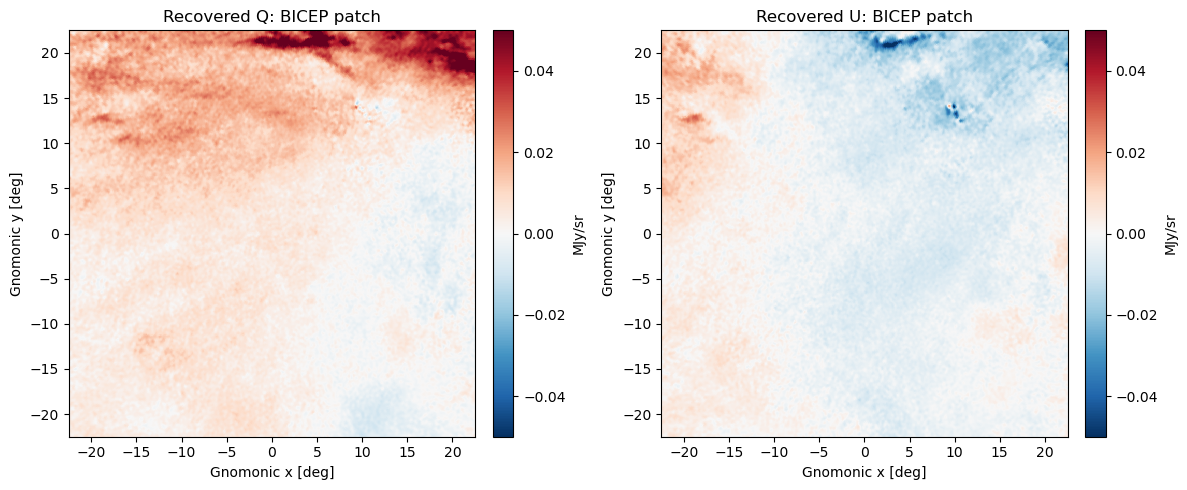

In [25]:

def bicep_center_galactic():
    """
    Approximate BICEP/Keck field center.

    Uses Equatorial center RA=0 deg, Dec=-57.5 deg and converts to Galactic.
    If astropy is unavailable, falls back to approximate Galactic coordinates.
    """
    try:
        from astropy.coordinates import SkyCoord
        import astropy.units as u
        c = SkyCoord(ra=0.0 * u.deg, dec=-57.5 * u.deg, frame="icrs").galactic
        return float(c.l.deg), float(c.b.deg)
    except Exception:
        return 316.0, -59.0


def get_square_patch_gnomonic(map_values, center_l_deg, center_b_deg, size_deg=20.0):
    """
    Return a square gnomonic cutout of a HEALPix map.

    The projected pixel size is set to the approximate HEALPix pixel size of
    the input map, so the image grid is close to one projected pixel per
    HEALPix-resolution element.
    """
    nside_map = hp.get_nside(map_values)
    reso_arcmin = hp.nside2resol(nside_map, arcmin=True)
    xsize = int(np.round(size_deg * 60.0 / reso_arcmin))

    img = hp.gnomview(
        map_values,
        rot=(center_l_deg, center_b_deg, 0.0),
        xsize=xsize,
        ysize=xsize,
        reso=reso_arcmin,
        return_projected_map=True,
        no_plot=True,
    )

    return np.asarray(img), reso_arcmin


def plot_bicep_patch(name="recovered_f", components=("Q", "U"), size_deg=20.0,
                     vlim=0.1, cmap="RdBu_r", dpi=180, filename = None):
    """
    Plot Q/U square cutouts centered on the BICEP patch.

    Valid map keys:
        'recovered', 'recovered_f', 'franken', 'MN', 'observed', 'observed_f', 'GNILC', 'nuisance', 'nuisance_f'

    Examples:
        plot_bicep_patch("recovered_f")
        plot_bicep_patch("GNILC", vlim=0.05)
        plot_bicep_patch("observed", components=("Q",), size_deg=20)
    """
    if name not in maps:
        raise KeyError(f"Unknown map {name!r}. Available keys: {list(maps.keys())}")

    center_l, center_b = bicep_center_galactic()
    label = maps[name].get("label", name)

    ncomp = len(components)
    fig, axes = plt.subplots(1, ncomp, figsize=(6 * ncomp, 5), dpi=dpi)
    if ncomp == 1:
        axes = [axes]

    for ax, comp in zip(axes, components):
        img, reso_arcmin = get_square_patch_gnomonic(
            maps[name][comp],
            center_l_deg=center_l,
            center_b_deg=center_b,
            size_deg=size_deg,
        )

        im = ax.imshow(
            img,
            origin="lower",
            cmap=cmap,
            vmin=-vlim,
            vmax=+vlim,
            extent=[-size_deg / 2, size_deg / 2, -size_deg / 2, size_deg / 2],
            interpolation="nearest",
        )

        ax.set_title(f"{label} {comp}: BICEP patch")
        ax.set_xlabel("Gnomonic x [deg]")
        ax.set_ylabel("Gnomonic y [deg]")
        ax.set_aspect("equal")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="MJy/sr")

    print(f"BICEP center used: l={center_l:.2f} deg, b={center_b:.2f} deg")
    print(f"Patch size: {size_deg:.1f} deg x {size_deg:.1f} deg")
    print(f"Projected pixel size: {reso_arcmin:.3f} arcmin")

    plt.tight_layout()
    if filename is not None:
        plt.savefig(f'{filename}')
    plt.show()


# Choose the map key here.
plot_bicep_patch("franken", size_deg=45.0, vlim=0.05, filename = 'BICEP.png', dpi=100)


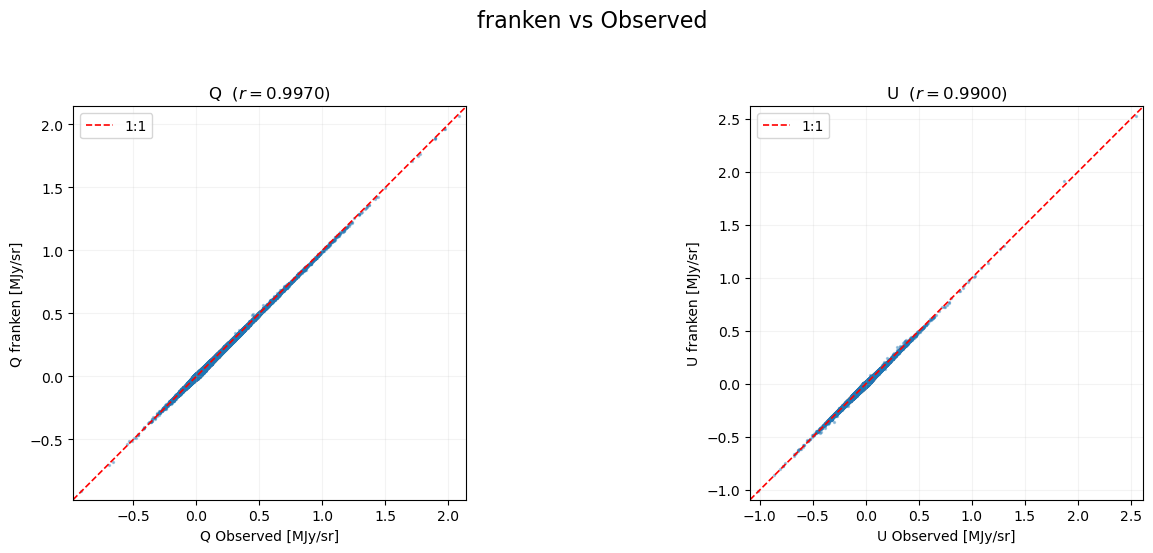

In [22]:

def plot_pixel_comparison(
    map_x,
    map_y,
    mask=None,
    max_points=300_000,
    point_size=2,
    alpha=0.35,
    dpi=180,
    title=None,
    label_x=None,
    label_y=None,
    filename=None,
    seed=0,
):
    """
    Pixel-by-pixel Q/U comparison between any two maps in `maps`.

    Parameters
    ----------
    map_x, map_y : str
        Keys in the `maps` dictionary. map_x is shown on the x-axis and
        map_y on the y-axis.
    mask : array-like of bool or None
        Optional sky mask. If None, all finite pixels shared by both maps
        are used.
    max_points : int or None
        Randomly subsample this many valid pixels for plotting. Correlation
        coefficients are computed from all valid pixels.
    label_x, label_y : str or None
        Explicit display labels. If None, the labels stored in `maps` are used.
    """

    if map_x not in maps or map_y not in maps:
        raise KeyError(f"Available map keys: {list(maps.keys())}")

    if label_x is None:
        label_x = maps[map_x].get("label", map_x)
    if label_y is None:
        label_y = maps[map_y].get("label", map_y)

    arrays = {
        "Q": (
            np.asarray(maps[map_x]["Q"]),
            np.asarray(maps[map_y]["Q"]),
        ),
        "U": (
            np.asarray(maps[map_x]["U"]),
            np.asarray(maps[map_y]["U"]),
        ),
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), dpi=dpi)

    rng = np.random.default_rng(seed)

    for ax, component in zip(axes, ("Q", "U")):
        x, y = arrays[component]

        valid = (
            np.isfinite(x)
            & np.isfinite(y)
            & (x != hp.UNSEEN)
            & (y != hp.UNSEEN)
        )

        if mask is not None:
            mask_array = np.asarray(mask, dtype=bool)
            if mask_array.shape != x.shape:
                raise ValueError(
                    f"mask shape {mask_array.shape} does not match map shape {x.shape}"
                )
            valid &= mask_array

        x_all = x[valid]
        y_all = y[valid]

        if x_all.size < 2:
            raise ValueError(f"Fewer than two valid pixels for {component}")

        r = np.corrcoef(x_all, y_all)[0, 1]

        if max_points is not None and x_all.size > max_points:
            idx = rng.choice(x_all.size, size=max_points, replace=False)
            x_plot = x_all[idx]
            y_plot = y_all[idx]
        else:
            x_plot = x_all
            y_plot = y_all

        lo = min(np.nanmin(x_plot), np.nanmin(y_plot))
        hi = max(np.nanmax(x_plot), np.nanmax(y_plot))
        pad = 0.02 * (hi - lo if hi > lo else 1.0)
        limits = (lo - pad, hi + pad)

        ax.scatter(
            x_plot,
            y_plot,
            s=point_size,
            alpha=alpha,
            rasterized=True,
        )
        ax.plot(
            limits,
            limits,
            "r--",
            lw=1.2,
            label="1:1",
        )

        ax.set_xlim(limits)
        ax.set_ylim(limits)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel(f"{component} {label_x} [MJy/sr]")
        ax.set_ylabel(f"{component} {label_y} [MJy/sr]")
        ax.set_title(rf"{component}  ($r={r:.4f}$)")
        ax.legend(loc="upper left")
        ax.grid(alpha=0.15)

    if title is None:
        title = f"{label_y} vs {label_x}"

    fig.suptitle(math_label(title), fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.94))

    if filename is not None:
        fig.savefig(
            filename,
            dpi=dpi,
            bbox_inches="tight",
            pad_inches=0.03,
        )

    plt.show()


# ------------------------------------------------------------------
# Choose the maps here.
# The first map is placed on the x-axis; the second on the y-axis.
# ------------------------------------------------------------------
comparison_map_x = "observed_f"
comparison_map_y = "franken"

plot_pixel_comparison(
    comparison_map_x,
    comparison_map_y,
    mask=None,  # e.g. mask=mask for an existing covered-sky mask
    # title="Recovered vs observed, pixel-by-pixel",
    label_x="Observed",
    label_y="franken",
    filename='scatter.png',  # e.g. "recovered_vs_observed.png"
    dpi=100,
)


/Users/tsouros/anaconda3/envs/stl/lib/python3.11/site-packages/healpy/visufunc.py:468: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(5.8, 6.4))


Map key: nuisance
Component: Q
Centre: l=0.000 deg, b=90.000 deg
Field size: 45.000 deg x 45.000 deg
Projected pixel size: 3.435 arcmin
Projected grid: 786 x 786 pixels


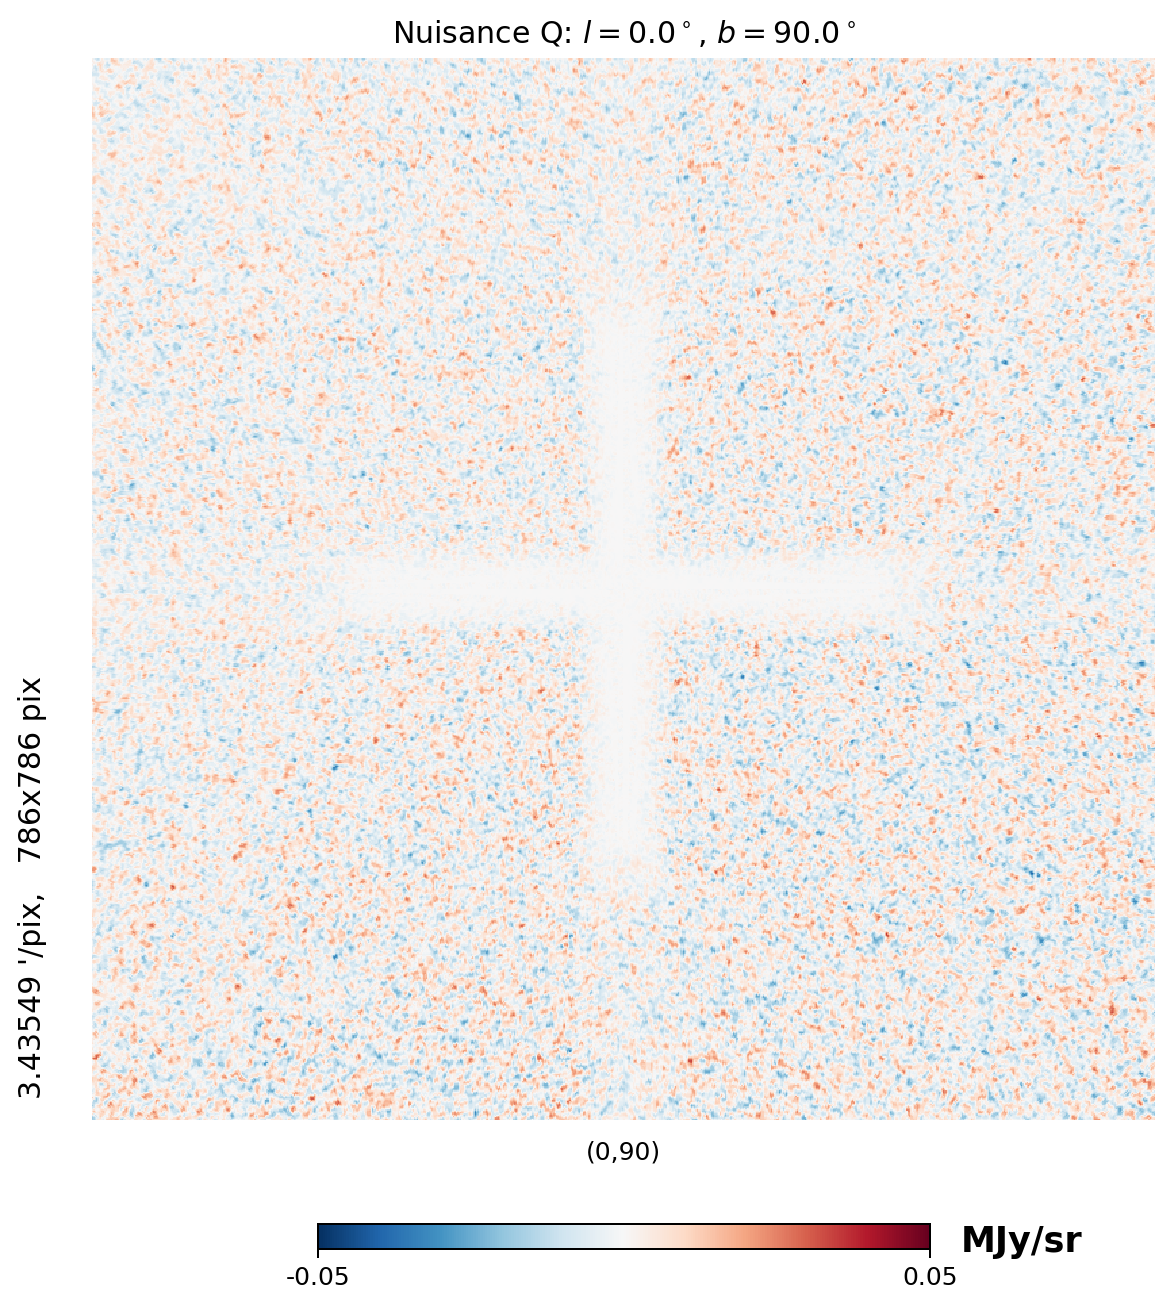

In [23]:

def plot_custom_gnomonic(
    name,
    component="Q",
    center_l_deg=0.0,
    center_b_deg=0.0,
    size_deg=20.0,
    vlim=0.1,
    cmap="RdBu_r",
    reso_arcmin=None,
    dpi=180,
    title=None,
    filename=None,
    name2 = None
):
    """
    Plot a selectable full-sky HEALPix map in a square gnomonic projection.

    Parameters
    ----------
    name : str
        Key in the `maps` dictionary.
    component : {"Q", "U"}
        Polarization component to plot.
    center_l_deg, center_b_deg : float
        Galactic longitude and latitude of the projection centre, in degrees.
    size_deg : float
        Width and height of the square field, in degrees.
    reso_arcmin : float or None
        Projected pixel size in arcminutes. If None, use the approximate
        HEALPix pixel resolution of the selected map.
    """

    if name not in maps:
        raise KeyError(
            f"Unknown map {name!r}. Available keys: {list(maps.keys())}"
        )

    if component not in ("Q", "U"):
        raise ValueError("component must be 'Q' or 'U'")
    
    if name2 is None:
        map_values = np.asarray(maps[name][component])
        # map_values = np.sqrt(np.asarray(maps[name]['Q'])**2 + np.asarray(maps[name]['U'])**2)
        nside_map = hp.get_nside(map_values)
    else:
        map_values = np.asarray(maps[name][component]) - np.asarray(maps[name2][component])
        nside_map = hp.get_nside(map_values)


    if reso_arcmin is None:
        reso_arcmin = hp.nside2resol(nside_map, arcmin=True)

    xsize = max(int(np.round(size_deg * 60.0 / reso_arcmin)), 1)

    label = maps[name].get("label", name)

    if title is None:
        title = (
            rf"{label} {component}: "
            rf"$l={center_l_deg:.1f}^\circ$, "
            rf"$b={center_b_deg:.1f}^\circ$"
        )

    fig = plt.figure(figsize=(8, 8), dpi=dpi)

    hp.gnomview(
        map_values,
        rot=(center_l_deg, center_b_deg, 0.0),
        xsize=xsize,
        ysize=xsize,
        reso=reso_arcmin,
        title=title,
        unit="MJy/sr",
        cmap=cmap,
        min=-vlim,
        max=+vlim,
        fig=fig.number,
    )

    if filename is not None:
        fig.savefig(
            filename,
            dpi=dpi,
            bbox_inches="tight",
            pad_inches=0,
        )

    print(f"Map key: {name}")
    print(f"Component: {component}")
    print(
        f"Centre: l={center_l_deg:.3f} deg, "
        f"b={center_b_deg:.3f} deg"
    )
    print(f"Field size: {size_deg:.3f} deg x {size_deg:.3f} deg")
    print(f"Projected pixel size: {reso_arcmin:.3f} arcmin")
    print(f"Projected grid: {xsize} x {xsize} pixels")

    plt.show()

plot_custom_gnomonic(
    name="nuisance",
    component="Q",
    center_l_deg=0,
    center_b_deg=90,
    size_deg=45.0,
    vlim=0.05,
    reso_arcmin=None,
    title=None,
    filename=None,
    dpi=180,
    # name2 = "franken"
)
